# Step 2 — Exploratory analysis

Profiling the cleaned sales to find the shape of the business and the quirks worth describing. Figures and tables are saved under `results/eda/`; this notebook walks the key ones.

In [1]:
# Setup: run from the project root so the data directory and results/
# resolve exactly as they do in main.py, and the step modules import.
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.path.join(os.getcwd(), "src"))

import pandas as pd
from IPython.display import Image, display

DATA_DIR = "kaggle_customer_intelligence"


In [2]:
# Small loaders for the artefacts the earlier steps saved.
def load_sales():
    p = f"{DATA_DIR}/clean_sales.parquet"
    try:
        return pd.read_parquet(p)
    except Exception:
        df = pd.read_csv(f"{DATA_DIR}/clean_sales.csv", parse_dates=["InvoiceDate"])
        df["CustomerID"] = df["CustomerID"].astype("Int64")
        return df

def load_customer_sales():
    s = load_sales()
    return s[s["CustomerID"].notna()].reset_index(drop=True)


In [3]:
from retail_eda import RetailEDA

sales = load_sales()
eda = RetailEDA(sales).run()

EXPLORATORY ANALYSIS
Revenue over time: 25 months, 1 partial.
Top products: saved revenue and quantity rankings (the lists differ).
Country labels present: ['Australia', 'Austria', 'Bahrain', 'Belgium', 'Bermuda', 'Brazil', 'Canada', 'Channel Islands', 'Cyprus', 'Czech Republic', 'Denmark', 'EIRE', 'European Community', 'Finland', 'France', 'Germany', 'Greece', 'Hong Kong', 'Iceland', 'Israel', 'Italy', 'Japan', 'Korea', 'Lebanon', 'Lithuania', 'Malta', 'Netherlands', 'Nigeria', 'Norway', 'Poland', 'Portugal', 'RSA', 'Saudi Arabia', 'Singapore', 'Spain', 'Sweden', 'Switzerland', 'Thailand', 'USA', 'United Arab Emirates', 'United Kingdom', 'Unspecified', 'West Indies']
Basket sizes: median 15 products, median spend GBP 301.23.
Long tail: top 20% of customers hold 77.2% of revenue; 27.6% buy only once.
Extreme orders: largest single line is 80,995 units.
Day of week: no-trade days = none.
Price variation: 88.8% of products sell at more than one price.
Anonymous: 22.6% of rows, 13.1% of r

### Revenue over time

25 months of trade. The partial final month (December 2011, data stops on the 9th) is flagged in red so it isn't read as a collapse. The shape is a gift-and-homeware seller's: a heavy autumn run-up to Christmas, with 2010 the only complete calendar year.

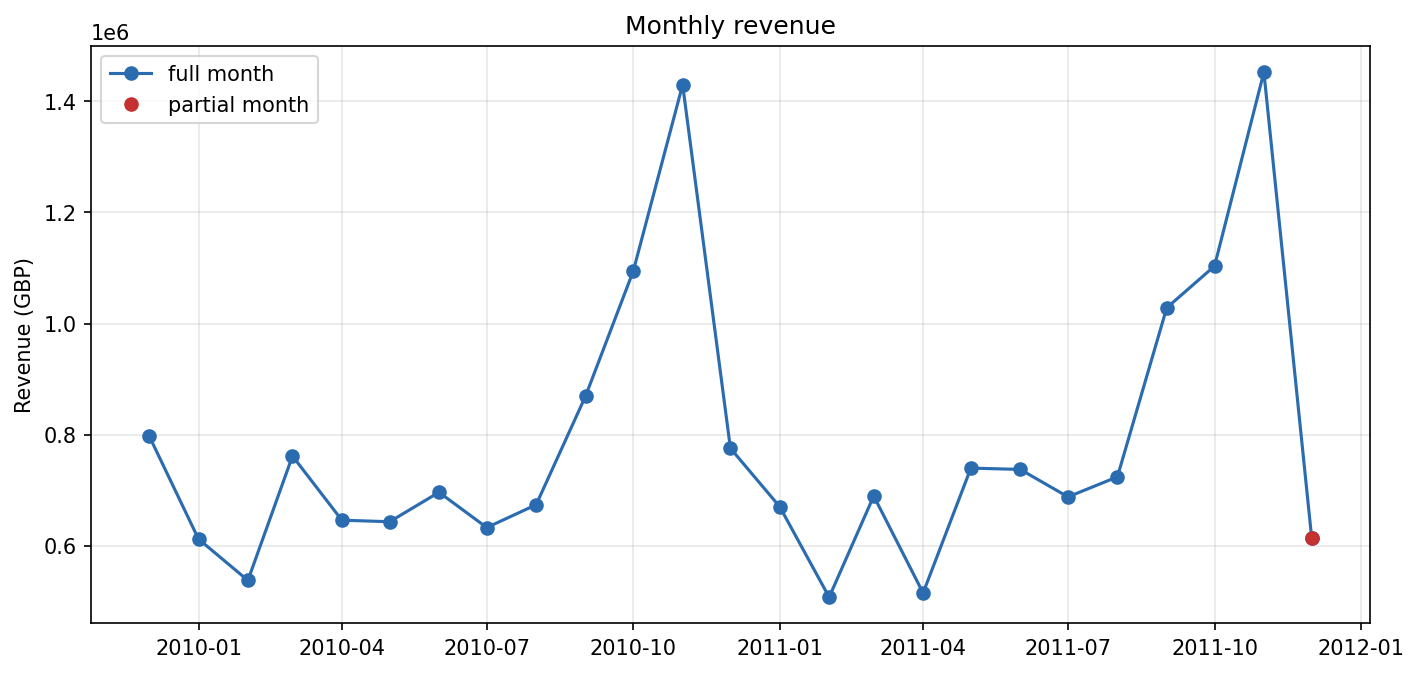

In [4]:
display(Image(filename="results/eda/figures/revenue_over_time.png"))

### The long tail of customers

The headline finding: the **top 20% of customers hold about 77% of revenue**, and roughly **28% of customers bought only once**. Revenue is concentrated in a small core, which is what makes segmentation worth doing.

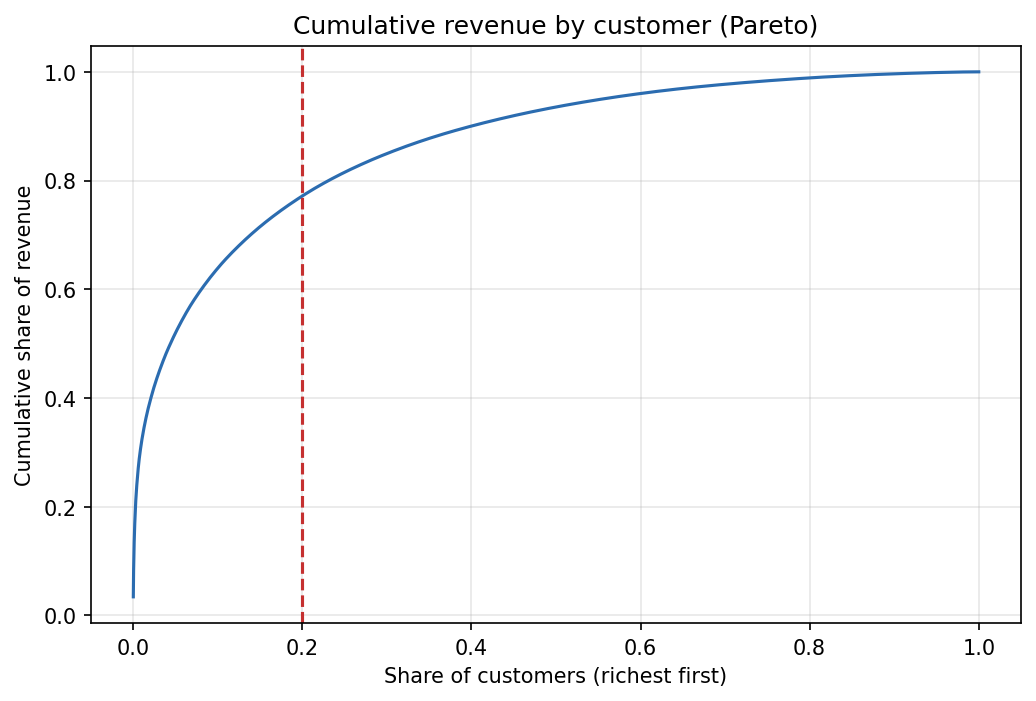

,metric,value
0,customers,5852.0000
1,top_20%_revenue_share,0.7715
2,one_time_buyer_rate,0.2765
3,repeat_buyer_rate,0.7235


In [5]:
display(Image(filename="results/eda/figures/customer_pareto.png"))
eda.tables["customer_summary"]

### Country and average order value

The UK is about 92% of rows, so a plain row count just rediscovers that. Average order value is the more telling cut: a few overseas markets place large orders, which is the first sign of wholesale behaviour and feeds the wholesaler question in segmentation.

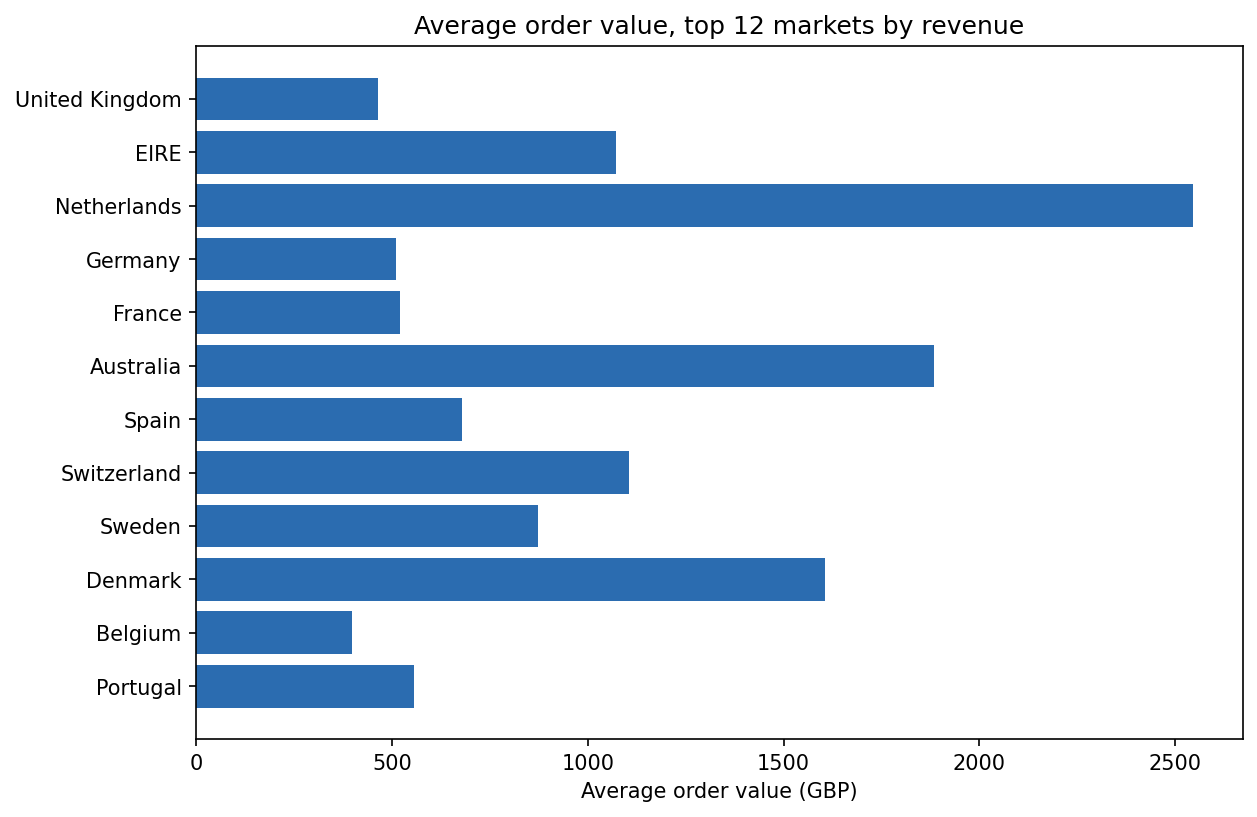

,rows,invoices,revenue,row_share_%,revenue_share_%,avg_order_value
Country,,,,,,
United Kingdom,923443,36184,16799849.90,92.05,85.53,464.29
EIRE,16913,581,623414.16,1.69,3.17,1073.00
Netherlands,4981,216,549773.41,0.50,2.80,2545.25
Germany,15787,753,383289.00,1.57,1.95,509.02
France,13160,598,311090.29,1.31,1.58,520.22
Australia,1783,89,167800.01,0.18,0.85,1885.39
Spain,3560,144,97766.75,0.35,0.50,678.94
Switzerland,3068,85,94024.59,0.31,0.48,1106.17
Sweden,1285,99,86319.14,0.13,0.44,871.91


In [6]:
display(Image(filename="results/eda/figures/country_avg_order_value.png"))
eda.tables["country_split"].head(10)

### Basket sizes

Median basket is about 15 distinct products and roughly £301 of spend, but the distribution is heavily right-skewed: a thin tail of enormous wholesale baskets. The histogram is clipped at the 99th percentile so the tail doesn't flatten everything else.

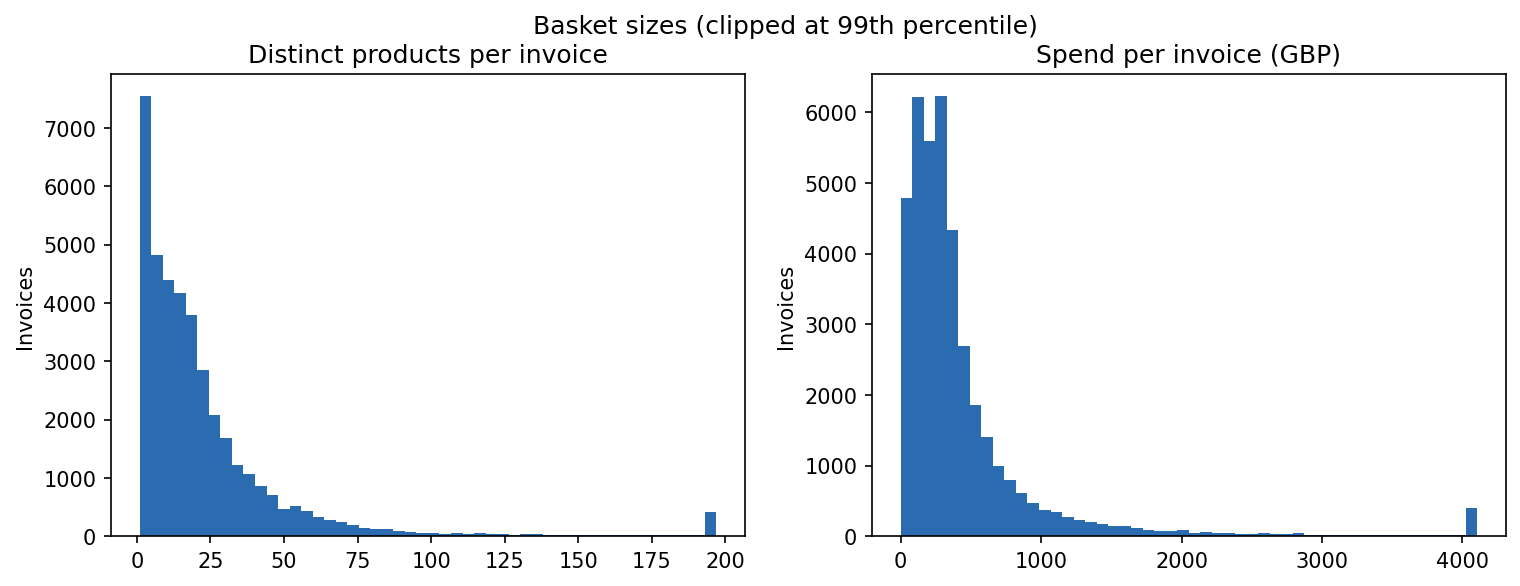

,n_products,n_units,spend
count,39516.000000,39516.000000,39516.000000
mean,25.101554,283.120103,497.081996
std,42.245526,1204.006098,1460.301911
min,1.000000,1.000000,0.190000
25%,6.000000,67.000000,150.320000
50%,15.000000,148.000000,301.230000
75%,28.000000,289.000000,484.400000
90%,51.000000,523.000000,905.560000
95%,73.000000,794.000000,1432.005000
99%,196.850000,2224.000000,4103.924000


In [7]:
display(Image(filename="results/eda/figures/basket_sizes.png"))
eda.tables["basket_size_stats"]

### Quirks worth noting

- **No empty trading days.** This copy of the data has invoices on every weekday including Saturday, so the often-repeated "no Saturdays" claim doesn't hold here.
- **Price variation:** about 89% of products sell at more than one price over the two years, consistent with wholesale and retail pricing side by side.
- **Anonymous rows:** about 23% of rows but only 13% of revenue have no Customer ID, so they skew towards smaller transactions. Kept for basket analysis, dropped for the customer work.

**Hands off to:** the findings here set the thresholds and transforms for the steps that follow. The skew in spend decides the log transform in segmentation; the one-time-buyer share decides the frequency scoring in RFM.